In [416]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import plotly.express as px
from matplotlib.ticker import FuncFormatter

In [417]:
dataframe = pd.read_csv('medical-charges.csv')

In [418]:
dataframe

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


<Axes: xlabel='age', ylabel='Count'>

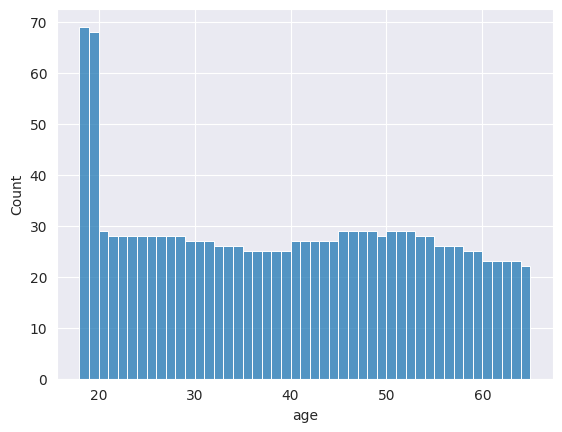

In [419]:
sns.histplot(data=dataframe,x='age',bins=47,binrange=[18,65])

In [420]:
smokers_by_sex = dataframe.groupby('sex')['smoker'].value_counts()

In [421]:

smokers_by_sex = smokers_by_sex.reset_index()

In [422]:
smokers_by_sex

,sex,smoker,count
0,female,no,547
1,female,yes,115
2,male,no,517
3,male,yes,159


<Axes: xlabel='smoker', ylabel='count'>

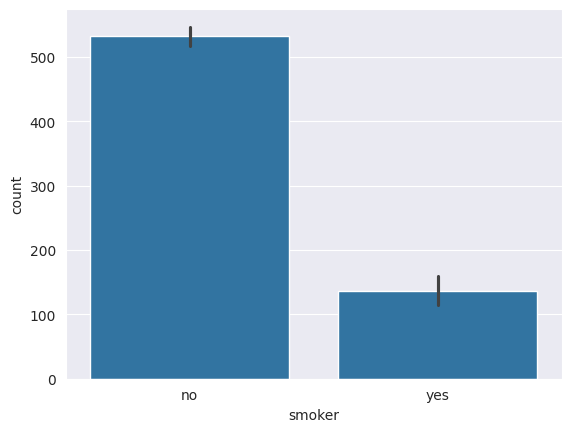

In [423]:
sns.barplot(data=smokers_by_sex,x='smoker',y='count')

In [424]:
age_charges = dataframe.groupby(['age','smoker'])['charges'].mean()

In [425]:
age_charges = age_charges.reset_index()

(array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
        35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
        52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64]),
 [Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23'),
  Text(24, 0, '24'),
  Text(25, 0, '25'),
  Text(26, 0, '26'),
  Text(27, 0, '27'),
  Text(28, 0, '28'),
  Text(29, 0, '29'),
  Text(30, 0, '30'),
  Text(31, 0, '31'),
  Text(32, 0, '32'),
  Text(33, 0, '33'),
  Text(34, 0, '34'),
  Text(35, 0, '35'),
  Text(36, 0, '36'),
  Text(37, 0, '37'),
  Text(38, 0, '38'),
  Text(39, 0, '39'),
  Text(40, 0, '40'),
  Text(41, 0, '41'),
  Text(42, 0, '42'),
  Text(43, 0, '43'),
  Text(44, 0, '44'),
  Text(45, 0, '45'),
  Text(46, 0, '46'),
  Text(47, 0, '47'),
  Text(48, 0, '48'),
  Text(49, 0, '49'),
  Text(50, 0, '50'),
  Text(51, 0, '51'),
  Text(52, 0, '52'),
  Text(53, 0, '53'),
  Text(54, 0, '54'),
  Text(55

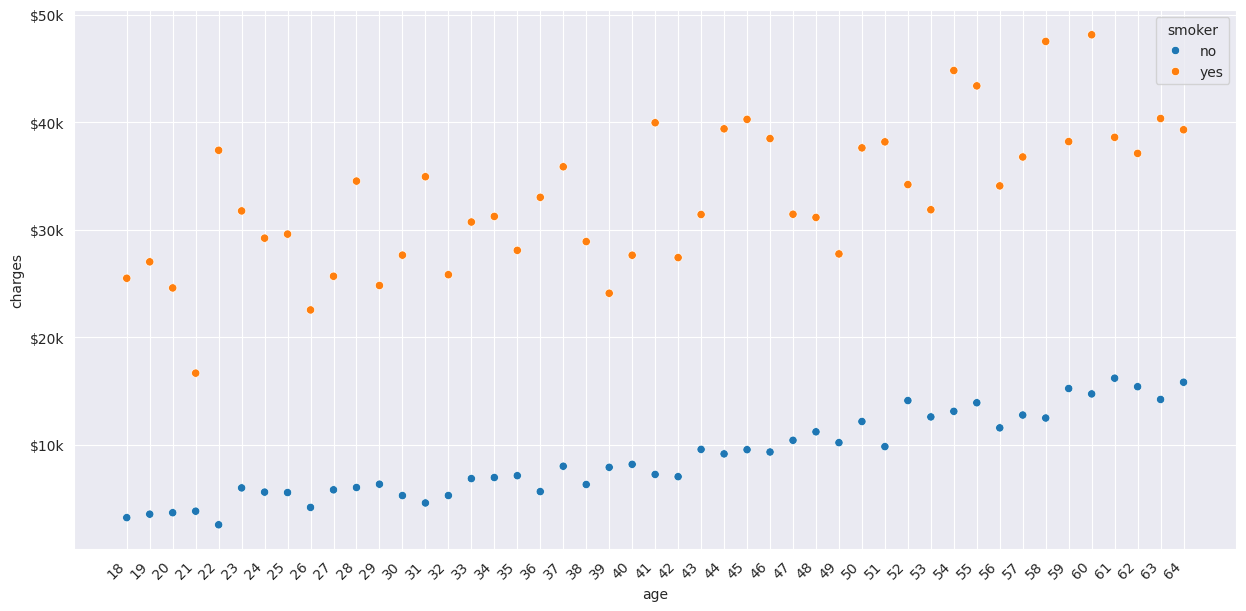

In [426]:
plt.figure(figsize=(15,7))
sns.scatterplot(data=age_charges,x='age',y='charges',hue='smoker')
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,pos: f'${int(x/1000)}k'))
ax.set_xticks(range(18,65))
plt.xticks(rotation=45,ha='right')

In [427]:
bmi_charges = dataframe.groupby(['sex','age','smoker','bmi'])['charges'].mean()
bmi_charges = bmi_charges.reset_index()
bmi_charges = bmi_charges.set_index('sex')

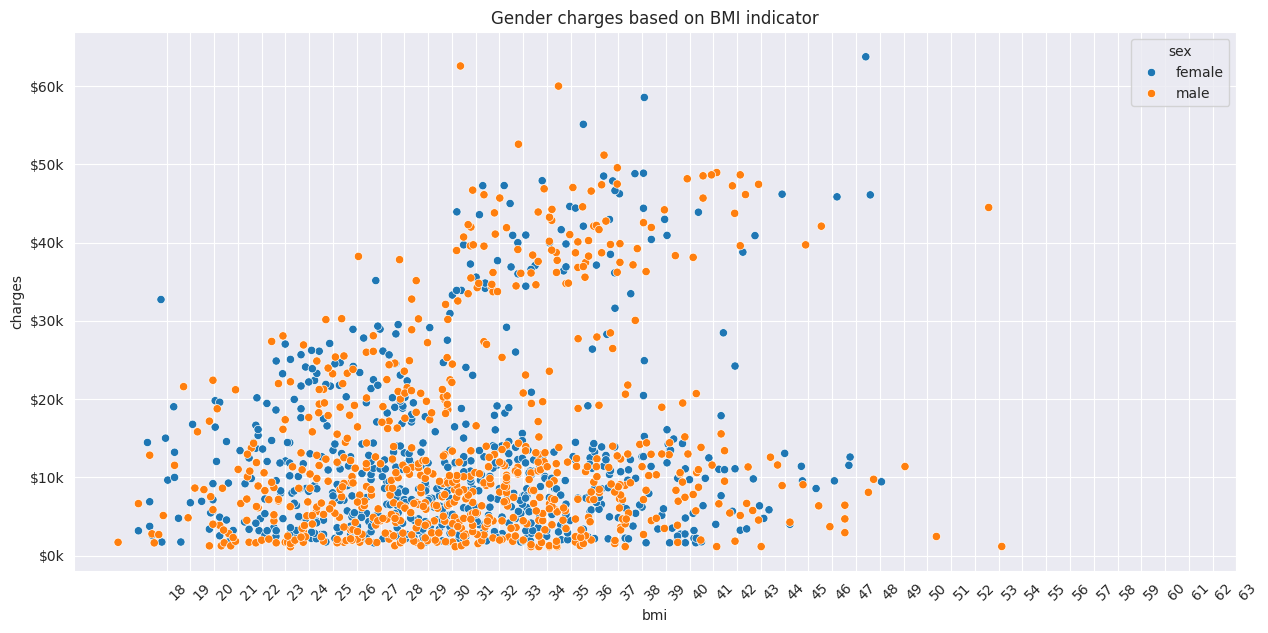

In [428]:
plt.figure(figsize=(15,7))
plt.title('Gender charges based on BMI indicator')
sns.scatterplot(data=bmi_charges,x='bmi',y='charges',hue='sex')
plt.xticks(range(18,64))
plt.xticks(rotation=45,ha='left')
ax = plt.gca()
ax.yaxis.set_major_formatter(FuncFormatter(lambda x,pos: f'${int(x/1000)}k'))

In [429]:
#convert category values into numerical values
smoker_values = {'no':0,'yes':1}
smoker_numeric = dataframe.smoker.map(smoker_values)
smoker_numeric

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    0
1335    0
1336    0
1337    1
Name: smoker, Length: 1338, dtype: int64

<Axes: xlabel='age', ylabel='charges'>

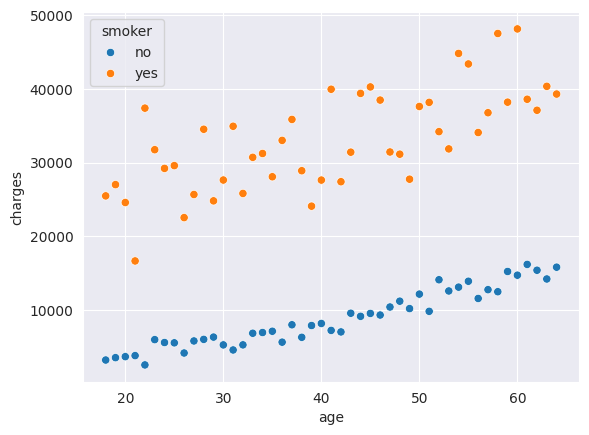

In [430]:
smoke = dataframe.groupby(['smoker','age'])['charges'].mean()
smoke = smoke.reset_index()
sns.scatterplot(data=smoke,x='age',y='charges',hue='smoker')


<Axes: xlabel='age', ylabel='smoker'>

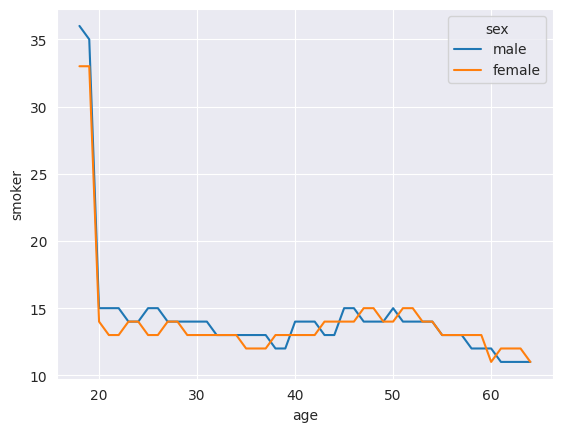

In [431]:
smokers_numbers_by_age = dataframe.groupby(['age','sex'])['smoker'].count()
smokers_numbers_by_age = smokers_numbers_by_age.reset_index()
smokers_numbers_by_age = smokers_numbers_by_age.sort_values(by='smoker',ascending=False)
sns.lineplot(data=smokers_numbers_by_age,x='age',y='smoker',hue='sex')

In [432]:
dataframe.region.unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [433]:
dataframe['sex_numeric'], dataframe['smoker_numeric'] ,dataframe['numeric_region'] = dataframe.sex.map({'female':0,'male':1}), dataframe.smoker.map({'yes':1,'no':0}),dataframe.region.map({'southwest':0, 'southeast':1, 'northwest':2, 'northeast':3})

In [443]:
numeric_dataframe = dataframe.drop(labels=['sex','smoker','region'],axis=1)

<Axes: >

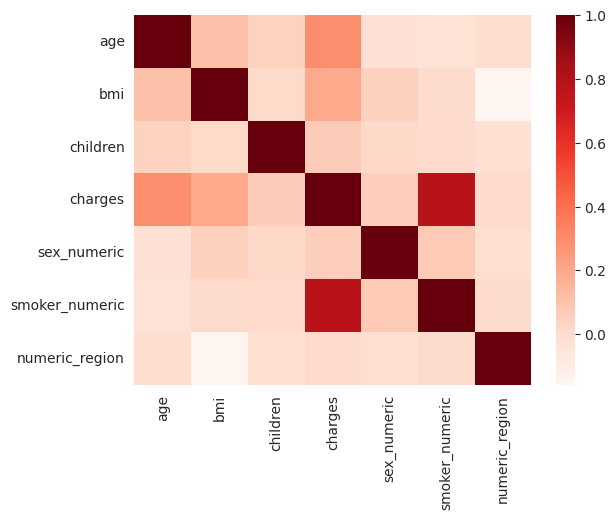

In [ ]:
sns.heatmap(data=numeric_dataframe.corr(),cmap='Reds',)

<Axes: >

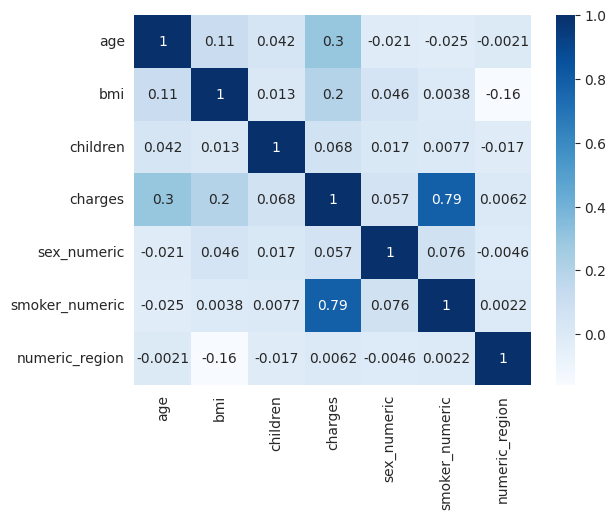

In [435]:
sns.heatmap(data=numeric_dataframe.corr(),cmap='Blues',annot=True)

In [436]:
non_smokers_df = dataframe[dataframe['smoker'] == 'no']

([<matplotlib.axis.XTick at 0x7cf50fa22930>,
 [Text(18, 0, '18'),
  Text(19, 0, '19'),
  Text(20, 0, '20'),
  Text(21, 0, '21'),
  Text(22, 0, '22'),
  Text(23, 0, '23'),
  Text(24, 0, '24'),
  Text(25, 0, '25'),
  Text(26, 0, '26'),
  Text(27, 0, '27'),
  Text(28, 0, '28'),
  Text(29, 0, '29'),
  Text(30, 0, '30'),
  Text(31, 0, '31'),
  Text(32, 0, '32'),
  Text(33, 0, '33'),
  Text(34, 0, '34'),
  Text(35, 0, '35'),
  Text(36, 0, '36'),
  Text(37, 0, '37'),
  Text(38, 0, '38'),
  Text(39, 0, '39'),
  Text(40, 0, '40'),
  Text(41, 0, '41'),
  Text(42, 0, '42'),
  Text(43, 0, '43'),
  Text(44, 0, '44'),
  Text(45, 0, '45'),
  Text(46, 0, '46'),
  Text(47, 0, '47'),
  Text(48, 0, '48'),
  Text(49, 0, '49'),
  Text(50, 0, '50'),
  Text(51, 0, '51'),
  Text(52, 0, '52'),
  Text(53, 0, '53'),
  Text(54, 0, '54'),
  Text(55, 0, '55'),
  Text(56, 0, '56'),
  Text(57, 0, '57'),
  Text(58, 0, '58'),
  Text(59, 0, '59'),
  Text(60, 0, '60'),
  Text(61, 0, '61'),
  Text(62, 0, '62'),
  Text(63,

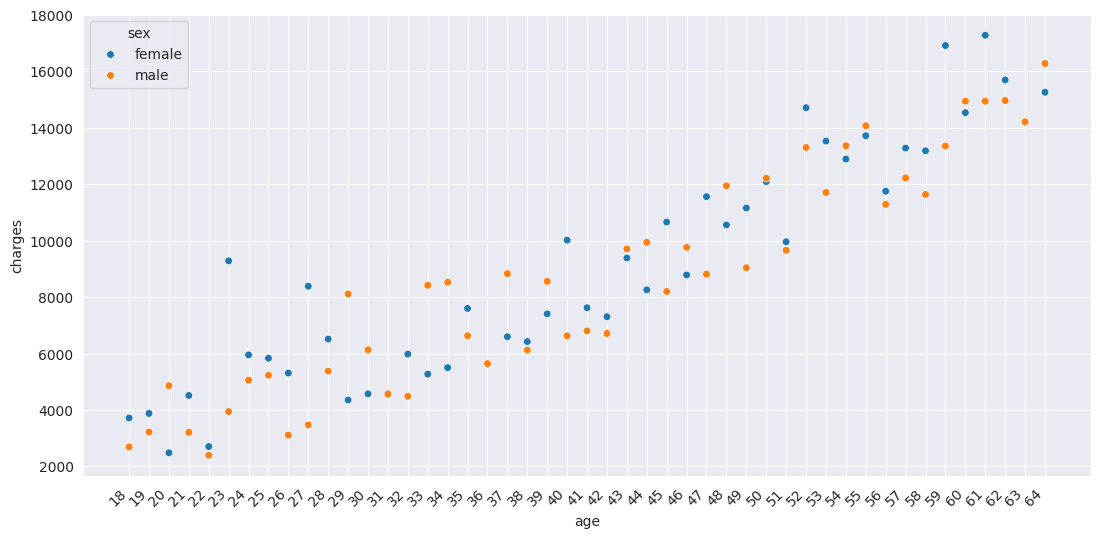

In [437]:
non_smokers_charges = non_smokers_df.groupby(['age','sex'])['charges'].mean()
non_smokers_charges = non_smokers_charges.reset_index()
plt.figure(figsize=(13,6))
sns.scatterplot(data=non_smokers_charges,x='age',y='charges',hue='sex',alpha=1,s=30)
sns.set_style('darkgrid')
plt.xticks(rotation=45,ha='right')
plt.xticks(range(18,65))

/tmp/ipykernel_1170742/385804254.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_smokers_df['predicted_charges'] = predictions


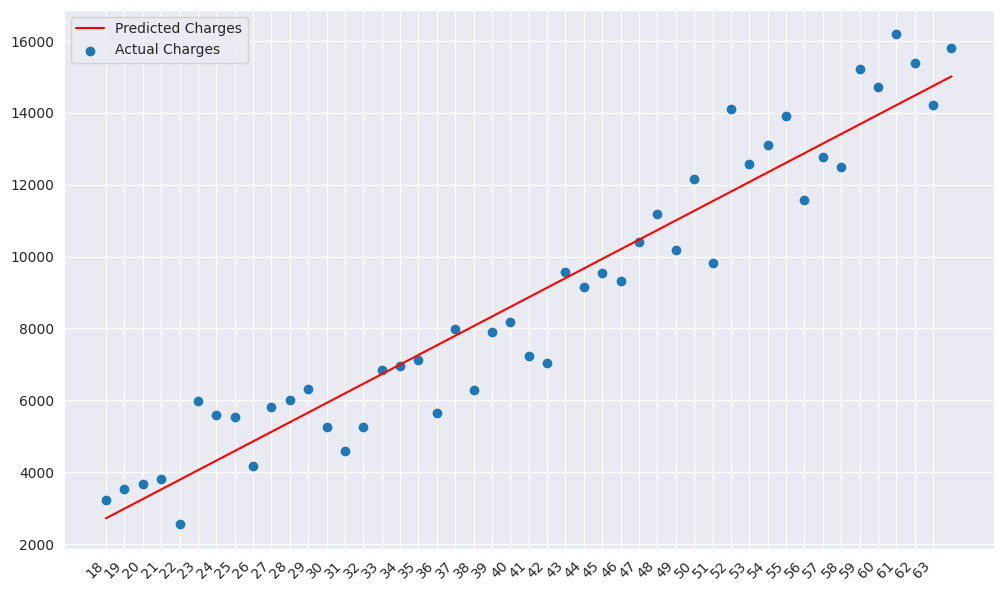

In [438]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
model = LinearRegression()
inputs = non_smokers_df[['age']]
targets = non_smokers_df['charges']
model.fit(inputs,targets)
predictions = model.predict(inputs)
mse = mean_squared_error(targets,predictions)
non_smokers_df['predicted_charges'] = predictions
actual_predicted = non_smokers_df.groupby('age').agg(actual=('charges','mean'),predicted=('predicted_charges','mean'))
actual_predicted = actual_predicted.reset_index()
plt.figure(figsize=(12,7))
plt.xticks(range(18,64))
plt.xticks(rotation=45,ha='right')
plt.plot(actual_predicted['age'],actual_predicted['predicted'],'r')
plt.scatter(actual_predicted['age'],actual_predicted['actual'])
plt.legend(['Predicted Charges','Actual Charges'])

In [ ]:
from sklearn.linear_model import GammaRegressor
from sklearn.metrics import mean_squared_error
model = GammaRegressor()
inputs = non_smokers_df[['age','bmi']]
targets = non_smokers_df['charges']
model.fit(inputs,targets)
pred = model.predict(inputs)
mse = mean_squared_error(targets,pred)
non_smokers_df['predicted_charges'] = pred
actual_predicted = non_smokers_df.groupby('age').agg(actual=('charges','mean'),predicted=('predicted_charges','mean'))
actual_predicted = actual_predicted.reset_index()
int(mse/10000)
plt.figure(figsize=(12,7))
plt.plot(actual_predicted['age'],actual_predicted['predicted'],'r')
plt.xticks(rotation=45,ha='right')
plt.xticks(range(18,64))
plt.scatter(actual_predicted['age'],actual_predicted['actual'])

/tmp/ipykernel_1170742/3850155744.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_smokers_df['predicted_charges'] = pred


2166

/tmp/ipykernel_1170742/3781135993.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_smokers_df['predicted_charges'] = pred


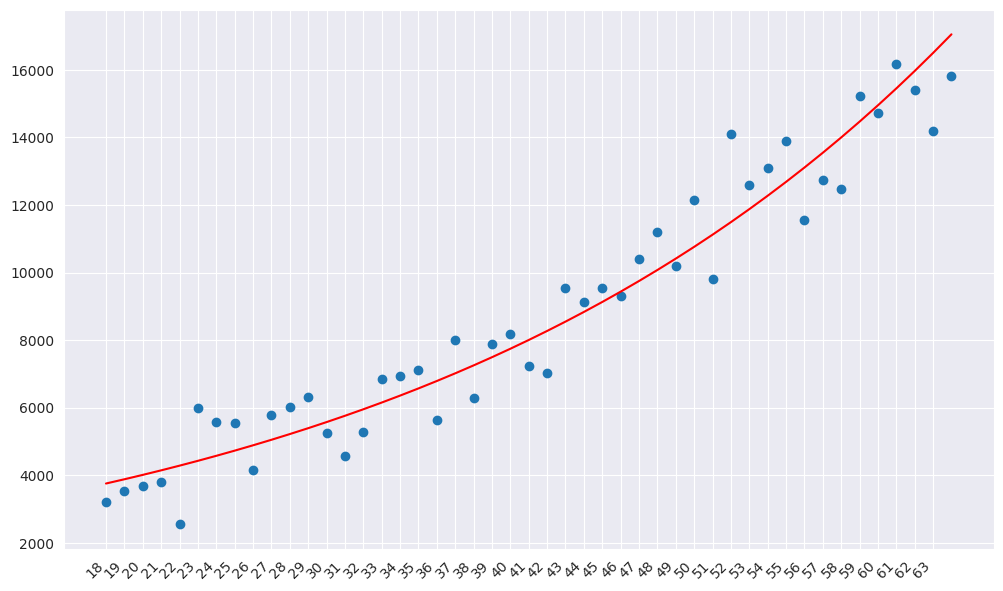

In [440]:
from sklearn.linear_model import PoissonRegressor
from sklearn.metrics import mean_squared_error
model = PoissonRegressor()
inputs = non_smokers_df[['age']]
targets = non_smokers_df['charges']
model.fit(inputs,targets)
pred = model.predict(inputs)
mse = mean_squared_error(targets,pred)
non_smokers_df['predicted_charges'] = pred
actual_predicted = non_smokers_df.groupby('age').agg(actual=('charges','mean'),predicted=('predicted_charges','mean'))
actual_predicted = actual_predicted.reset_index()
plt.figure(figsize=(12,7))
plt.plot(actual_predicted['age'],actual_predicted['predicted'],'r')
plt.xticks(rotation=45,ha='right')
plt.xticks(range(18,64))
plt.scatter(actual_predicted['age'],actual_predicted['actual'])

/tmp/ipykernel_1170742/258735309.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_smokers_df['predicted_charges'] = pred


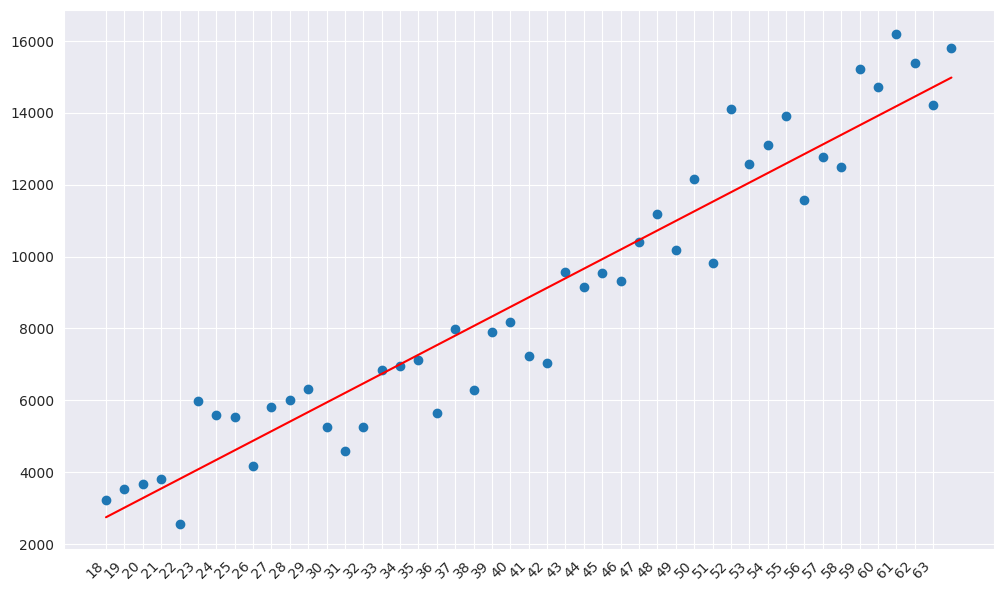

In [441]:
from sklearn.linear_model import TweedieRegressor
from sklearn.metrics import mean_squared_error
model = TweedieRegressor()
inputs = non_smokers_df[['age']]
targets = non_smokers_df['charges']
model.fit(inputs,targets)
pred = model.predict(inputs)
mse = mean_squared_error(targets,pred)
non_smokers_df['predicted_charges'] = pred
actual_predicted = non_smokers_df.groupby('age').agg(actual=('charges','mean'),predicted=('predicted_charges','mean'))
actual_predicted = actual_predicted.reset_index()
plt.figure(figsize=(12,7))
plt.plot(actual_predicted['age'],actual_predicted['predicted'],'r')
plt.xticks(rotation=45,ha='right')
plt.xticks(range(18,64))
plt.scatter(actual_predicted['age'],actual_predicted['actual'])